## Visualización de los datos (Punto a)

En este apartado se realiza la carga y visualización de la base de datos *BreastCancer.csv*, la cual contiene información de 569 observaciones con dos características por muestra, junto con su respectiva etiqueta de clasificación (0 o 1).

El objetivo es explorar la distribución de los datos en el espacio de características y analizar visualmente si existe separación entre las clases.

In [ ]:
import pandas as pd

# Cargar el archivo
data = pd.read_csv("BreastCancer.csv")

# Mostrar las primeras filas
data.head()

,radius_mean,smoothness_mean,pronostic
0,0.950308,1.523620,1
1,1.646970,-0.893636,1
2,1.409349,0.891658,1
3,-0.823748,3.254336,1
4,1.571363,0.223788,1


In [ ]:
data['grupo_dup'] = data.groupby(['radius_mean', 'smoothness_mean']).ngroup()

duplicados = data[data.duplicated(subset=['radius_mean', 'smoothness_mean'], keep=False)]

duplicados.sort_values('grupo_dup')

,radius_mean,smoothness_mean,pronostic,grupo_dup
237,-1.830667,-0.754317,0,0
260,-1.830667,-0.754317,0,0
386,-1.820406,-1.163656,0,1
391,-1.820406,-1.163656,0,1
215,-1.580355,0.024146,0,4
...,...,...,...,...
389,-0.000176,-0.632952,0,202
235,0.142937,-0.967604,0,227
466,0.142937,-0.967604,0,227
429,0.153738,0.118222,0,228


In [ ]:
duplicados.groupby(['radius_mean', 'smoothness_mean']).indices

{(np.float64(-1.83066714748449),
  np.float64(-0.75431715574495)): array([15, 26]),
 (np.float64(-1.82040624193292),
  np.float64(-1.16365648396954)): array([ 98, 101]),
 (np.float64(-1.58035505679235),
  np.float64(0.0241457070541041)): array([ 1, 60]),
 (np.float64(-1.47720595361608),
  np.float64(-1.94858259931951)): array([  3, 102]),
 (np.float64(-1.36784630234282),
  np.float64(0.518225457612914)): array([10, 40, 81]),
 (np.float64(-1.35947556360339),
  np.float64(0.266876747299566)): array([ 59, 110, 120]),
 (np.float64(-1.34111394314269),
  np.float64(0.374597623148144)): array([72, 82]),
 (np.float64(-1.29277967751821),
  np.float64(-0.881427789246271)): array([33, 48, 69, 94]),
 (np.float64(-1.28278879579695),
  np.float64(-1.98808025379732)): array([ 25, 125]),
 (np.float64(-1.2733379617363),
  np.float64(-1.24552434961446)): array([89, 91]),
 (np.float64(-1.24066507826947),
  np.float64(0.238151180406612)): array([ 52, 117]),
 (np.float64(-1.18558021688738),
  np.float64(-0

### Carga y organización de los datos

Se separan las variables del conjunto de datos en:

- $X \in \mathbb{R}^{m \times 2}$: matriz de características, donde cada fila corresponde a un vector $(x_1, x_2)$.
- $t \in \{0,1\}^m$: vector de etiquetas, donde cada valor indica la clase real de cada observación.

Se asume que la última columna del conjunto de datos corresponde a la variable objetivo.

In [ ]:
# Separar características y etiquetas
X = data.iloc[:, :-1].values   # x1, x2
t = data.iloc[:, -1].values    # etiquetas

# Ver dimensiones
print("Shape de X:", X.shape)
print("Shape de t:", t.shape)

Shape de X: (469, 2)
Shape de t: (469,)


### Gráfico de dispersión

Se construye un gráfico de dispersión para representar cada observación en el plano $(x_1, x_2)$.

Para facilitar la interpretación:

- Las observaciones con $t = 0$ se representan en color azul.
- Las observaciones con $t = 1$ se representan en color rojo.

Esto permite visualizar la distribución de los datos en el espacio de características.

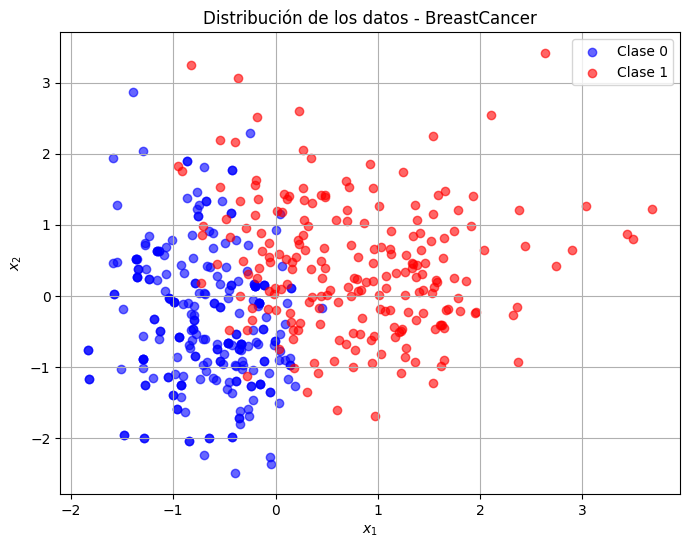

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Clase 0
plt.scatter(X[t == 0, 0], X[t == 0, 1],
            color='blue', label='Clase 0', alpha=0.6)
# Selecciona SOLO los puntos cuya etiqueta es 0
# X[t == 0, 0] → valores de x1 de clase 0
# X[t == 0, 1] → valores de x2 de clase 0
# Se grafican en azul

# Clase 1
plt.scatter(X[t == 1, 0], X[t == 1, 1],
            color='red', label='Clase 1', alpha=0.6)
# Selecciona SOLO los puntos cuya etiqueta es 1
# Se grafican en rojo

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Distribución de los datos - BreastCancer")

plt.legend()   # Muestra la leyenda (Clase 0, Clase 1)
plt.grid()

plt.show()

### Análisis visual

A partir del gráfico de dispersión, se observa que las clases presentan una tendencia de separación en el espacio de características, principalmente a lo largo del eje $x_1$. Sin embargo, existe una región de solapamiento entre ambas clases, lo que indica que los datos no son perfectamente separables de forma lineal.

A pesar de esto, una frontera de decisión lineal puede aproximar adecuadamente la separación entre clases, lo cual justifica el uso de un modelo de regresión logística.

## Frontera de decisión (Punto b)

En este apartado se implementa una función que permite graficar la frontera de decisión asociada a un vector de parámetros:

$$
w = [w_1, w_2, w_3]^T
$$

La frontera de decisión está definida por la ecuación:

$$
w_1 x_1 + w_2 x_2 + w_3 = 0
$$

Despejando $x_2$, se obtiene:

$$
x_2 = \frac{-w_1 x_1 - w_3}{w_2}
$$

Esta forma permite representar la recta en el plano $(x_1, x_2)$ y visualizar cómo el modelo separa las clases observadas en el punto (a).

In [ ]:
def plot_recta(w, X, t):
    import numpy as np
    import matplotlib.pyplot as plt

    # Crear figura
    plt.figure(figsize=(8,6))

    # Graficar datos (igual que punto a)
    # Clase 0 (t == 0)
    plt.scatter(X[t == 0, 0], X[t == 0, 1],
                color='blue', label='Clase 0', alpha=0.6)

    # Clase 1 (t == 1)
    plt.scatter(X[t == 1, 0], X[t == 1, 1],
                color='red', label='Clase 1', alpha=0.6)

    # Construcción de la recta
    # Generar valores de x1 dentro del rango de los datos
    x_vals = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100)

    # Caso general (w2 != 0)
    if abs(w[1]) > 1e-10:
        y_vals = (-w[0]*x_vals - w[2]) / w[1]
        plt.plot(x_vals, y_vals, 'k-', label='Frontera de decisión')

    # Caso especial: recta vertical
    else:
        x_const = -w[2] / w[0]
        plt.axvline(x=x_const, color='k', label='Recta vertical')

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title("Frontera de decisión sobre los datos")

    plt.legend()
    plt.grid()

    plt.show()

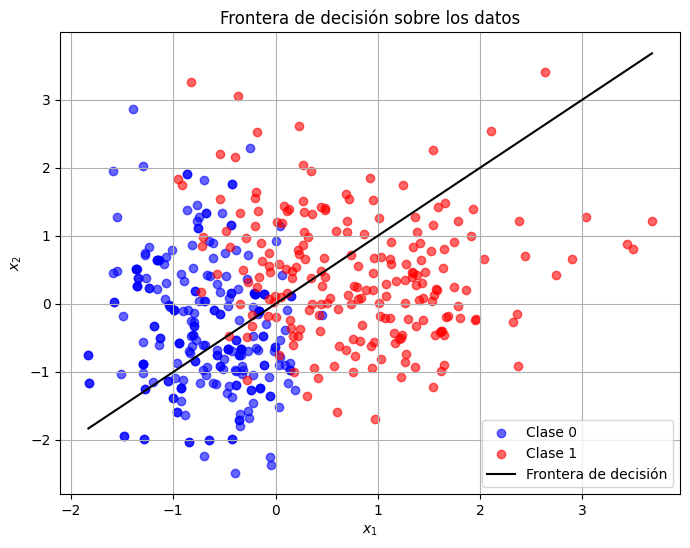

In [ ]:
# Ejemplo de vector de parámetros
w = np.array([1, -1, 0])

# Graficar frontera de decisión
plot_recta(w, X, t)

### Análisis de la frontera de decisión

La recta obtenida presenta una inclinación positiva y atraviesa la región central de los datos, separando parcialmente las clases.

Se observa que la frontera de decisión logra capturar la tendencia general de separación entre las clases, sin embargo, existe un solapamiento significativo, lo que genera errores de clasificación.

Este comportamiento es consistente con el análisis previo del conjunto de datos, donde se evidenció que las clases no son perfectamente separables de manera lineal.

Es importante destacar que el vector de parámetros $w$ utilizado en este apartado no es óptimo, sino que se emplea únicamente para ilustrar la construcción de la frontera de decisión.

## Función de pérdida (Punto c)

Se define una función que permite evaluar qué tan bueno es un vector de parámetros $w$ para clasificar los datos.

La función de pérdida en regresión logística está dada por:

$$
f(w) = -\frac{1}{m} \sum_{i=1}^{m} \left[ t_i \log(y_i) + (1 - t_i)\log(1 - y_i) \right]
$$

donde:

$$
y_i = \frac{1}{1 + e^{-w^T z^{(i)}}}
$$

y $z^{(i)} = (x_1^{(i)}, x_2^{(i)}, 1)$.

Esta función mide el error del modelo al comparar las predicciones $y_i$ con las etiquetas reales $t_i$.

In [ ]:
import numpy as np

def sigmoid(z):
    """
    Función sigmoide:
    transforma cualquier valor real en un valor entre 0 y 1
    """
    return 1 / (1 + np.exp(-z))

In [ ]:
def loss_function(w, X, t):
    """
    Calcula la función de pérdida de regresión logística

    w: vector de parámetros (w1, w2, w3)
    X: matriz de datos (x1, x2)
    t: etiquetas (0 o 1)
    """

    m = len(t)

    # Construir z = (x1, x2, 1)
    Z = np.hstack([X, np.ones((m,1))])

    # Predicciones
    y = sigmoid(Z @ w)

    # Evitar log(0)
    epsilon = 1e-10
    y = np.clip(y, epsilon, 1 - epsilon)

    # Función de pérdida
    f = -(1/m) * np.sum(t * np.log(y) + (1 - t) * np.log(1 - y))

    return f

### Interpretación

La función de pérdida mide la diferencia entre las predicciones del modelo y las etiquetas reales.

- Si $y_i$ es cercano a $t_i$, la pérdida es pequeña.
- Si $y_i$ es muy diferente de $t_i$, la pérdida aumenta.

Por lo tanto, valores pequeños de $f(w)$ indican que el modelo clasifica mejor los datos.



In [ ]:
# Ejemplo de vector w
w = np.array([1, -1, 0])

# Calcular pérdida
valor_loss = loss_function(w, X, t)

print("f(w) =", valor_loss)

f(w) = 0.6870220839104795


### Relación con los siguientes apartados

La función de pérdida será utilizada para comparar distintos vectores de parámetros $w$.

En particular, en el punto (d) se evaluarán varios candidatos y se seleccionará aquel que produzca el menor valor de $f(w)$, ya que esto indica una mejor capacidad de clasificación.

## Evaluación de candidatos (Punto d)

En este apartado se evalúan distintos vectores de parámetros $w$ con el objetivo de comparar su desempeño como clasificadores.

Cada candidato define una frontera de decisión diferente, y su calidad se mide mediante la función de pérdida $f(w)$.

Se espera que el mejor clasificador sea aquel que minimice el valor de la función de pérdida.

In [ ]:
# Candidatos dados en el enunciado
candidatos = [
    np.array([0.0603, 4.0364, 1.3192]),
    np.array([-1.345, 3.597, -0.588]),
    np.array([0.0603, 1.000, 0.502])
]

In [ ]:
# Evaluar cada candidato
for i, w in enumerate(candidatos):
    valor = loss_function(w, X, t)
    print(f"Candidato {i+1}:")
    print("w =", w)
    print("f(w) =", valor)
    print("-"*40)

Candidato 1:
w = [0.0603 4.0364 1.3192]
f(w) = 1.1171134255652402
----------------------------------------
Candidato 2:
w = [-1.345  3.597 -0.588]
f(w) = 1.4253273452014
----------------------------------------
Candidato 3:
w = [0.0603 1.     0.502 ]
f(w) = 0.6493193274279888
----------------------------------------


### Análisis de resultados

Se calcula el valor de la función de pérdida para cada candidato.

Dado que la función de pérdida mide el error del modelo, el mejor vector de parámetros será aquel que produzca el menor valor de $f(w)$.

Esto indica que las predicciones del modelo son más cercanas a las etiquetas reales.

In [ ]:
# Encontrar el mejor candidato
valores = [loss_function(w, X, t) for w in candidatos]

mejor_idx = np.argmin(valores)
mejor_w = candidatos[mejor_idx]

print("Mejor candidato:", mejor_idx + 1)
print("w óptimo:", mejor_w)

Mejor candidato: 3
w óptimo: [0.0603 1.     0.502 ]


## Análisis visual de los candidatos (Punto e)

En este apartado se grafican las fronteras de decisión asociadas a cada uno de los vectores $w$ propuestos en el punto (d).

El objetivo es comparar visualmente la capacidad de cada modelo para separar las clases y relacionar esta observación con los valores obtenidos de la función de pérdida $f(w)$.

Candidato 1


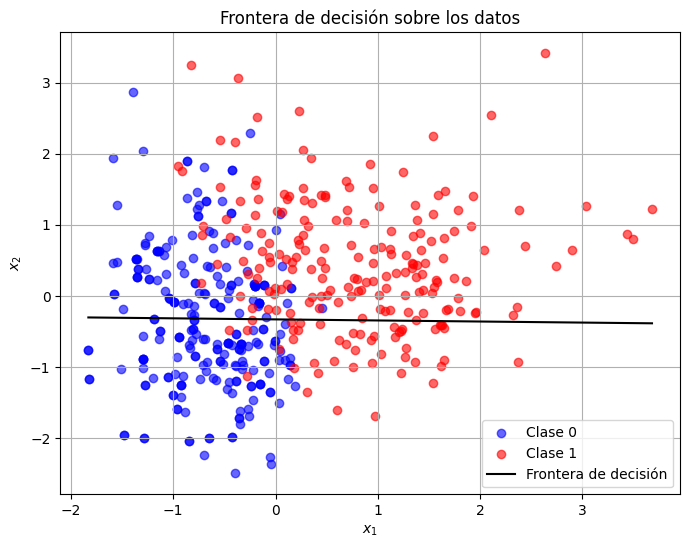

Candidato 2


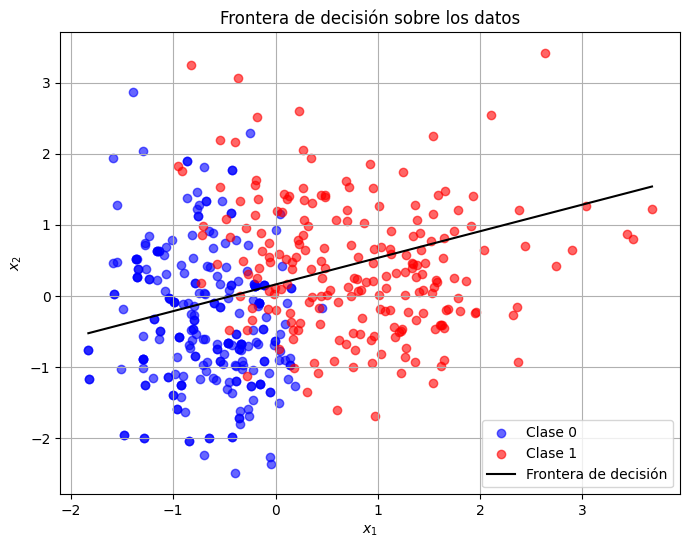

Candidato 3


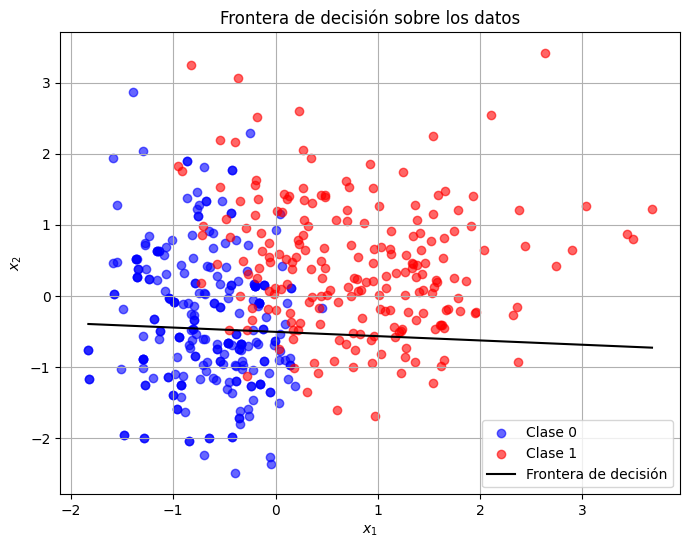

In [ ]:
for i, w in enumerate(candidatos):
    print(f"Candidato {i+1}")
    plot_recta(w, X, t)

### Análisis de resultados

A partir de los valores obtenidos de la función de pérdida, se observa que el candidato 3 presenta el menor valor de $f(w)$, lo que indica un mejor desempeño del modelo.

Aunque visualmente su frontera de decisión no separa perfectamente las clases, logra un mejor ajuste global en términos probabilísticos, lo cual es consistente con la naturaleza de la regresión logística.

Esto evidencia que la mejor frontera de decisión no necesariamente corresponde a la que visualmente parece más separadora, sino a aquella que minimiza la función de pérdida.

## Gradiente y Hessiana (Punto f)

En este apartado se implementan el gradiente y la matriz Hessiana de la función de pérdida de la regresión logística.

El gradiente está dado por:

$$
\nabla f(w) = \frac{1}{m} \sum_{i=1}^{m} (y_i - t_i)\, z^{(i)}
$$

y la matriz Hessiana por:

$$
F(w) = \frac{1}{m} \sum_{i=1}^{m} y_i (1 - y_i)\, z^{(i)} (z^{(i)})^T
$$

Estas expresiones permiten analizar la pendiente y la curvatura de la función de pérdida.

In [ ]:
def gradient(w, X, t):
    """
    Calcula el gradiente de la función de pérdida

    w: vector de parámetros
    X: datos
    t: etiquetas
    """

    m = len(t)

    # Construir z = (x1, x2, 1)
    Z = np.hstack([X, np.ones((m,1))])

    # Predicciones
    y = sigmoid(Z @ w)

    # Gradiente
    grad = (1/m) * (Z.T @ (y - t))

    return grad

In [ ]:
def hessian(w, X, t):
    """
    Calcula la matriz Hessiana
    """

    m = len(t)

    Z = np.hstack([X, np.ones((m,1))])

    y = sigmoid(Z @ w)

    # Matriz diagonal
    D = np.diag(y * (1 - y))

    # Hessiana
    H = (1/m) * (Z.T @ D @ Z)

    return H

In [ ]:
for i, w in enumerate(candidatos):
    print(f"Candidato {i+1}")

    grad = gradient(w, X, t)
    H = hessian(w, X, t)

    print("Gradiente:", grad)
    print("Norma del gradiente:", np.linalg.norm(grad))
    print("Hessiana:\n", H)
    print("-"*50)

Candidato 1
Gradiente: [-0.28000648  0.16189668  0.15276762]
Norma del gradiente: 0.357703943167849
Hessiana:
 [[ 0.07692541  0.00175094  0.00288322]
 [ 0.00175094  0.02176841 -0.02514309]
 [ 0.00288322 -0.02514309  0.08637066]]
--------------------------------------------------
Candidato 2
Gradiente: [-0.44078326  0.14172474 -0.03558868]
Norma del gradiente: 0.464373060359812
Hessiana:
 [[0.09623497 0.03106947 0.00496521]
 [0.03106947 0.02892317 0.01026364]
 [0.00496521 0.01026364 0.09432526]]
--------------------------------------------------
Candidato 3
Gradiente: [-0.31214392  0.01112377  0.14757028]
Norma del gradiente: 0.345448340125208
Hessiana:
 [[ 0.18762982  0.02974826 -0.00548253]
 [ 0.02974826  0.14063429 -0.03507823]
 [-0.00548253 -0.03507823  0.19973619]]
--------------------------------------------------


### Análisis del gradiente

El gradiente indica la dirección de mayor incremento de la función de pérdida.

- Si el gradiente es cercano a cero, el modelo se encuentra cerca de un punto óptimo.
- Si el gradiente es grande, el modelo aún puede mejorar significativamente.

Por lo tanto, se esperaba que el mejor candidato (con menor $f(w)$) tuviera un gradiente de menor magnitud.

### Análisis de la Hessiana

La Hessiana describe la curvatura de la función de pérdida.

En regresión logística, la Hessiana es siempre positiva definida, lo que implica que la función de pérdida es convexa.

Esto garantiza la existencia de un único mínimo global, facilitando el proceso de optimización.

### Conclusión

El análisis del gradiente y la Hessiana permite comprender el comportamiento de la función de pérdida.

Se observa que el mejor candidato no solo minimiza la función de pérdida, sino que también presenta un gradiente de menor magnitud, lo cual indica cercanía a un punto óptimo.

Además, la positividad de la Hessiana confirma que la función es convexa, lo que garantiza estabilidad en la optimización del modelo.

In [ ]:
!jupyter nbconvert --to html "challenge_week3.ipynb" #Crear .html

[NbConvertApp] Converting notebook challenge_week3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 726824 bytes to challenge_week3.html
